In [2]:
!pip install numpy
!pip install pandas

In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df1=pd.read_excel('/content/CS_1.1 (1).xlsx')
df2=pd.read_excel('/content/CS_2.1 (1).xlsx')

df1.head()
print(df1.shape,df2.shape)

(51336, 26) (51336, 62)


In [5]:
#clean df1
df1 = df1.loc[df1['Age_Oldest_TL'] != -99999]

In [7]:
#clean df2
columns_to_be_removed=[]

for col in df2.columns:
  if df2.loc[df2[col]==-99999].shape[0]>0:
    columns_to_be_removed.append(col)
df2=df2.drop(columns_to_be_removed,axis=1)
print("dropped columns:",columns_to_be_removed)

dropped columns: ['time_since_recent_payment', 'time_since_first_deliquency', 'time_since_recent_deliquency', 'max_delinquency_level', 'max_deliq_6mts', 'max_deliq_12mts', 'tot_enq', 'CC_enq', 'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'enq_L3m', 'pct_currentBal_all_TL', 'CC_utilization', 'PL_utilization', 'max_unsec_exposure_inPct']


In [8]:
#merge two dataframes
df=pd.merge(df1,df2,how='inner',on='PROSPECTID')
print(df.shape)
print(df['Approved_Flag'].value_counts())

(51296, 66)
Approved_Flag
P2    32162
P3     7449
P4     5882
P1     5803
Name: count, dtype: int64


In [9]:
print(df1.shape,df2.shape)

(51296, 26) (51336, 41)


In [10]:
#feature selection
for col in df.columns:
  if df[col].dtype == 'object':
    print(col)

MARITALSTATUS
EDUCATION
GENDER
last_prod_enq2
first_prod_enq2
Approved_Flag


In [13]:
from scipy.stats import chi2_contingency
for col in ['MARITALSTATUS','EDUCATION','GENDER','last_prod_enq2','first_prod_enq2']:
  chi2,pval, _, _ = chi2_contingency(pd.crosstab(df[col],df['Approved_Flag']))
  print(col, '---',round(pval,5))



MARITALSTATUS --- 0.0
EDUCATION --- 0.0
GENDER --- 0.00026
last_prod_enq2 --- 0.0
first_prod_enq2 --- 0.0


In [14]:
#variance_inflation_factor for numerical factors
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_columns=[col for col in df.columns
                 if df[col].dtype != 'object'
                 and col not in ['PROSPECTID','Approved_Flag']]

vif_data = df[numeric_columns].copy()
columns_to_be_kept = []
column_index = 0

for i in range(len(numeric_columns)):
    vif_value = variance_inflation_factor(vif_data.values, column_index)
    print(numeric_columns[i], '---', round(vif_value, 2))

    if vif_value <= 6:
        columns_to_be_kept.append(numeric_columns[i])
        column_index += 1
    else:
        vif_data = vif_data.drop(numeric_columns[i], axis=1)

Total_TL --- inf
Tot_Closed_TL --- inf
Tot_Active_TL --- 10.63
Total_TL_opened_L6M --- 7.93
Tot_TL_closed_L6M --- 6.4
pct_tl_open_L6M --- 5.3
pct_tl_closed_L6M --- 2.48
pct_active_tl --- inf
pct_closed_tl --- 894.76
Total_TL_opened_L12M --- 7.22
Tot_TL_closed_L12M --- 3.64
pct_tl_open_L12M --- 5.03
pct_tl_closed_L12M --- 4.96
Tot_Missed_Pmnt --- 1.91
Auto_TL --- inf
CC_TL --- 3.75
Consumer_TL --- 20.79
Gold_TL --- 26.1
Home_TL --- 4.44
PL_TL --- 2.7
Secured_TL --- 2.76
Unsecured_TL --- 3.56
Other_TL --- 2.16
Age_Oldest_TL --- 5.0
Age_Newest_TL --- 3.03
num_times_delinquent --- 7.89
max_recent_level_of_deliq --- 5.38
num_deliq_6mts --- inf
num_deliq_12mts --- 7.26
num_deliq_6_12mts --- 1.4
num_times_30p_dpd --- 8.47
num_times_60p_dpd --- 1.63
num_std --- 7.05
num_std_6mts --- 15.37
num_std_12mts --- 1.82
num_sub --- 1.56
num_sub_6mts --- 2.55
num_sub_12mts --- 3.1
num_dbt --- 2.19
num_dbt_6mts --- 7.38
num_dbt_12mts --- 2.07
num_lss --- 2.73
num_lss_6mts --- 6.29
num_lss_12mts --- 2.71


In [15]:
from scipy.stats import f_oneway

columns_to_be_kept_numerical = []

for col in columns_to_be_kept:
    groups = [df[col][df['Approved_Flag'] == grade].tolist()
              for grade in ['P1', 'P2', 'P3', 'P4']]

    f_stat, p_value = f_oneway(*groups)

    if p_value <= 0.05:
        columns_to_be_kept_numerical.append(col)

print("Final numerical features:", len(columns_to_be_kept_numerical))

Final numerical features: 32


In [16]:
features = columns_to_be_kept_numerical + ['MARITALSTATUS', 'EDUCATION', 'GENDER',
                                             'last_prod_enq2', 'first_prod_enq2']
df = df[features + ['Approved_Flag']]

# Ordinal encoding for EDUCATION (order matters here)
edu_map = {
    'SSC': 1, '12TH': 2, 'GRADUATE': 3,
    'UNDER GRADUATE': 3, 'POST-GRADUATE': 4,
    'OTHERS': 1, 'PROFESSIONAL': 3
}
df['EDUCATION'] = df['EDUCATION'].map(edu_map).astype(int)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import xgboost as xgb

X = df[features]
y = df['Approved_Flag']

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # P1→0, P2→1, P3→2, P4→3

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

numeric_feat = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_feat = [c for c in features if c not in numeric_feat]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_feat),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feat)
])

models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=20, min_samples_split=10),
    'XGBoost': xgb.XGBClassifier(objective='multi:softmax', num_class=4,
                                   eval_metric='mlogloss', use_label_encoder=False)
}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: Accuracy = {acc:.4f}")

RandomForest: Accuracy = 0.7286
DecisionTree: Accuracy = 0.6693
XGBoost: Accuracy = 0.7354


In [19]:
from itertools import product as iterproduct

X_train_proc = pd.get_dummies(X_train.copy(), drop_first=True)
X_test_proc = pd.get_dummies(X_test.copy(), drop_first=True)
X_train_proc, X_test_proc = X_train_proc.align(X_test_proc, join='left', axis=1, fill_value=0)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

best_acc, best_params = 0, None

for n_est, depth, lr in iterproduct(param_grid['n_estimators'],
                                     param_grid['max_depth'],
                                     param_grid['learning_rate']):
    model = xgb.XGBClassifier(
        objective='multi:softmax', num_class=4,
        eval_metric='mlogloss', use_label_encoder=False,
        n_estimators=n_est, max_depth=depth, learning_rate=lr
    )
    model.fit(X_train_proc, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_proc))

    if acc > best_acc:
        best_acc = acc
        best_params = {'n_estimators': n_est, 'max_depth': depth, 'learning_rate': lr}

print("Best params:", best_params)
print("Best accuracy:", round(best_acc, 4))

Best params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Best accuracy: 0.7392


In [21]:
# Rebuild best_xgb_model using the best params found above
X_train_proc = pd.get_dummies(X_train.copy(), drop_first=True)
X_test_proc = pd.get_dummies(X_test.copy(), drop_first=True)
X_train_proc, X_test_proc = X_train_proc.align(X_test_proc, join='left', axis=1, fill_value=0)

best_xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=200,       # your best param
    max_depth=5,            # your best param
    learning_rate=0.1       # your best param
)

best_xgb_model.fit(X_train_proc, y_train)
print("Model ready:", type(best_xgb_model))

Model ready: <class 'xgboost.sklearn.XGBClassifier'>


              precision    recall  f1-score   support

          P1       0.78      0.70      0.74      1161
          P2       0.77      0.92      0.84      6433
          P3       0.42      0.13      0.20      1490
          P4       0.59      0.56      0.58      1176

    accuracy                           0.74     10260
   macro avg       0.64      0.58      0.59     10260
weighted avg       0.70      0.74      0.71     10260



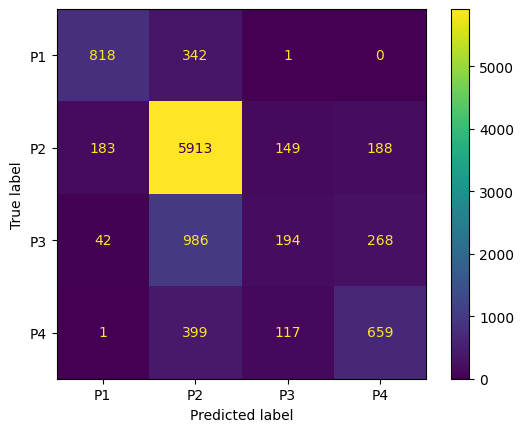

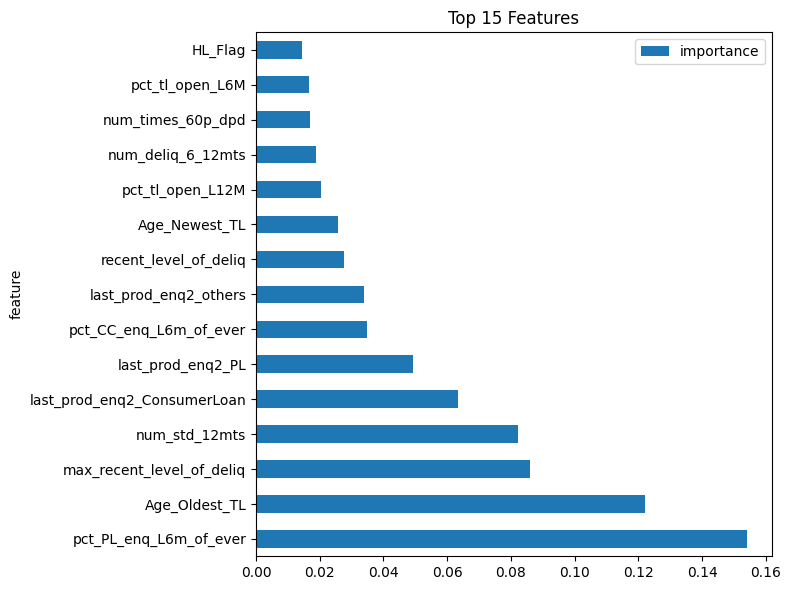

In [22]:
# 1. Check class distribution
df['Approved_Flag'].value_counts()

# 2. Full classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,
      best_xgb_model.predict(X_test_proc),
      target_names=['P1','P2','P3','P4']))

# 3. Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, best_xgb_model.predict(X_test_proc))
disp = ConfusionMatrixDisplay(cm, display_labels=['P1','P2','P3','P4'])
disp.plot()
plt.savefig("confusion_matrix.png")
plt.show()

# 4. Feature importance
feat_df = pd.DataFrame({
    'feature': X_train_proc.columns,
    'importance': best_xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

feat_df.plot(kind='barh', x='feature', y='importance', figsize=(8,6))
plt.title("Top 15 Features")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [23]:
import joblib

# Save model and preprocessor
joblib.dump(best_xgb_model, 'Loan_Approval_Model.pkl')
joblib.dump(X_train_proc.columns.tolist(), 'model_columns.pkl')

print("Saved successfully!")

Saved successfully!


In [24]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load model and column names
model = joblib.load('Loan_Approval_Model.pkl')
model_columns = joblib.load('model_columns.pkl')

st.set_page_config(page_title="CreditIQ", page_icon="🏦", layout="centered")

st.title("🏦 CreditIQ — Loan Risk Classifier")
st.write("Enter applicant details below to predict credit risk grade.")
st.markdown("---")

col1, col2 = st.columns(2)

with col1:
    age_oldest_tl = st.number_input("Age of Oldest Trade Line (months)", min_value=0, max_value=600, value=120)
    gender = st.selectbox("Gender", ["M", "F"])
    marital = st.selectbox("Marital Status", ["Married", "Single", "Others"])
    education = st.selectbox("Education Level",
                    ["SSC", "12TH", "GRADUATE", "UNDER GRADUATE",
                     "POST-GRADUATE", "PROFESSIONAL", "OTHERS"])

with col2:
    last_prod = st.selectbox("Last Product Enquiry",
                    ["AL", "CC", "ConsumerLoan", "HL", "PL", "others"])
    first_prod = st.selectbox("First Product Enquiry",
                    ["AL", "CC", "ConsumerLoan", "HL", "PL", "others"])
    num_enquiries = st.number_input("Number of Enquiries (Last 6 months)", min_value=0, max_value=50, value=1)
    active_loans = st.number_input("Number of Active Loans", min_value=0, max_value=30, value=2)

st.markdown("---")

edu_map = {
    "SSC": 1, "12TH": 2, "GRADUATE": 3,
    "UNDER GRADUATE": 3, "POST-GRADUATE": 4,
    "PROFESSIONAL": 3, "OTHERS": 1
}

if st.button("🔍 Predict Risk Grade", use_container_width=True):

    input_dict = {
        "Age_Oldest_TL": age_oldest_tl,
        "EDUCATION": edu_map[education],
        "GENDER": gender,
        "MARITALSTATUS": marital,
        "last_prod_enq2": last_prod,
        "first_prod_enq2": first_prod,
        "num_enquiries": num_enquiries,
        "active_loans": active_loans
    }

    input_df = pd.DataFrame([input_dict])
    input_encoded = pd.get_dummies(input_df)
    input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)

    prediction = model.predict(input_encoded)[0]

    grade_map = {
        0: ("P1 — Very Low Risk", "✅", "green"),
        1: ("P2 — Low Risk", "🟡", "orange"),
        2: ("P3 — Medium Risk", "🟠", "red"),
        3: ("P4 — High Risk", "🔴", "darkred")
    }

    label, icon, color = grade_map[prediction]

    st.markdown(f"""
    <div style='background-color:#1e1e2e;padding:20px;border-radius:10px;text-align:center'>
        <h2 style='color:{color}'>{icon} Predicted Grade: {label}</h2>
    </div>
    """, unsafe_allow_html=True)

    st.markdown("### What this means:")
    explanations = {
        0: "This applicant is highly creditworthy. Very low probability of default.",
        1: "This applicant is creditworthy with low risk. Loan likely to be approved.",
        2: "This applicant carries moderate risk. Manual review recommended.",
        3: "This applicant carries high risk. Loan approval not recommended."
    }
    st.info(explanations[prediction])

st.markdown("---")
st.caption("CreditIQ | Built by Nagapuri Shashi Kiran | NIT Warangal")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [25]:
!pip install streamlit -q
!streamlit run app.py &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 64.2 MB/s eta 0:00:00


2026-06-23 10:02:59.599 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.198.228.125:8501

  Stopping...


In [28]:
from pyngrok import ngrok

# Paste your token here
ngrok.set_auth_token("3FX8HwYZa0FvNTM8MaAPkdxdsPm_7p4Y6dok1XsTQVw216dxj")

# Create tunnel
public_url = ngrok.connect(8501)
print("✅ Your app is live at:", public_url)

✅ Your app is live at: NgrokTunnel: "https://wrist-hunting-pavestone.ngrok-free.dev" -> "http://localhost:8501"
